In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 1. Exploratory Data Analysis (EDA)
We will look at the dataset structure, statistics, and check for missing values.

In [2]:
df = pd.read_csv("Food_Delivery_Times (1).csv")

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [8]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [9]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

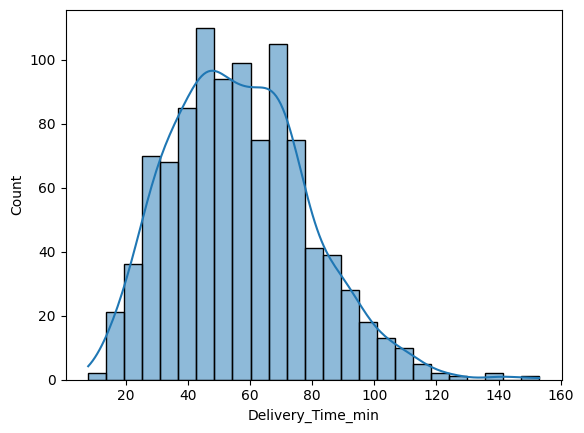

In [11]:
sns.histplot(df['Delivery_Time_min'] , kde=True)

In [12]:
# fill null values

cols = ['Weather', 'Traffic_Level', 'Time_of_Day']

# def fill(col):
#   df[col] = df[col].fillna(df[col].mode)
#   return df[col]

# for col in cols:
#   fill(col)


# second mehtod
df[cols].fillna(df[cols].mode)


# fill courier_experiance year fill by checking distribution

df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean() , inplace=True)



# if our data are skwed we perform log_transformation

/tmp/ipykernel_1465/3945458090.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean() , inplace=True)


In [13]:
df['Courier_Experience_yrs'].value_counts()

,count
Courier_Experience_yrs,
6.000000,109
9.000000,108
1.000000,107
8.000000,101
2.000000,99
4.000000,94
7.000000,91
0.000000,91
5.000000,90


### 2. Feature Engineering & Preprocessing
We will encode categorical variables manually using One-Hot Encoding and drop unnecessary columns like `Order_ID`.

In [14]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [15]:
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type']


df = pd.get_dummies(df , columns = cat_cols)

In [16]:
df.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True
1,738,16.42,20,2.0,84,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False
2,741,9.52,28,1.0,59,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True
3,661,7.44,5,1.0,37,False,False,True,False,False,False,False,True,True,False,False,False,False,False,True
4,412,19.03,16,5.0,68,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False


### 3. Data Splitting
Splitting the data into Features (X) and Target (y), then into Training and Testing sets.

In [17]:
X = df.drop(['Order_ID' , "Delivery_Time_min"] , axis = 1)
y = df['Delivery_Time_min']

### 4. Model Training & Evaluation
We will train a Decision Tree Regressor and a Random Forest Regressor, then compare their performance using Mean Absolute Error and R-squared.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt_model = DecisionTreeRegressor() # object of decision tree
rf_model = RandomForestRegressor() # object of random forest


In [20]:
# train both of the models
dt_model.fit(X_train , y_train)

rf_model.fit(X_train , y_train)

RandomForestRegressor()

In [21]:
# be never rely on one Scoring mertics for both regression & classification

In [22]:
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [23]:
y_pred_dt_train = dt_model.predict(X_train)
y_pred_rf_train = rf_model.predict(X_train)

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Decision Tree Regressor Metrics:\n")
print("Training R2 Score:", r2_score(y_train, y_pred_dt_train))
print("Training MAE:", mean_absolute_error(y_train, y_pred_dt_train))
print("Training MSE:", mean_squared_error(y_train, y_pred_dt_train))
print("Testing R2 Score:", r2_score(y_test, y_pred_dt))
print("Testing MAE:", mean_absolute_error(y_test, y_pred_dt))
print("Testing MSE:", mean_squared_error(y_test, y_pred_dt))

print("\nRandom Forest Regressor Metrics:\n")
print("Training R2 Score:", r2_score(y_train, y_pred_rf_train))
print("Training MAE:", mean_absolute_error(y_train, y_pred_rf_train))
print("Training MSE:", mean_squared_error(y_train, y_pred_rf_train))
print("Testing R2 Score:", r2_score(y_test, y_pred_rf))
print("Testing MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Testing MSE:", mean_squared_error(y_test, y_pred_rf))

Decision Tree Regressor Metrics:

Training R2 Score: 1.0
Training MAE: 0.0
Training MSE: 0.0
Testing R2 Score: 0.31915151943492837
Testing MAE: 12.063636363636364
Testing MSE: 330.4878787878788

Random Forest Regressor Metrics:

Training R2 Score: 0.9553822392093743
Training MAE: 3.0678059701492533
Training MSE: 21.682645820895523
Testing R2 Score: 0.783507096235419
Testing MAE: 6.952121212121213
Testing MSE: 105.08693575757577


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score
mae = mean_absolute_error
mse = mean_squared_error

In [26]:
# decision tree

print("testing" , r2(y_train , y_pred_dt_train))
print('Training' , r2(y_test , y_pred_dt))

testing 1.0
Training 0.31915151943492837


In [27]:
print("testing" , r2(y_train , y_pred_rf_train))
print('Training' , r2(y_test , y_pred_rf))

testing 0.9553822392093743
Training 0.783507096235419


# 5. Hyperparameter Tuning
We will use `GridSearchCV` to find the best parameters for the Random Forest Regressor to improve its generalization on the test set.

In [28]:
from sklearn.model_selection import GridSearchCV


param_grid =  {"n_estimators" : [100 , 200] ,# number of dicision tree
               "max_depth" : [10 , 20 , 30] ,
               "min_samples_split" : [2 , 5 , 8],
               "min_samples_leaf": [1 , 2, 4] }

grid_search = GridSearchCV(
    estimator=rf_model ,
    param_grid=param_grid ,
    scoring = 'neg_mean_absolute_error' ,
    cv = 3 ,
    n_jobs = -1 ,  # apke sytem me jitne core hain ye ab hyperparameter tune karne me use kra do
    verbose = 1   # disply the execution

)




In [29]:
# fit the model on training set
grid_search.fit(X_train , y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 8],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error', verbose=1)

In [30]:
# to check best parameter

grid_search.best_params_

{'max_depth': 30,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 100}

In [31]:
rf_grid = RandomForestRegressor(max_depth= 10,min_samples_leaf= 4, min_samples_split= 2,n_estimators= 200)

In [32]:
rf_grid.fit(X_train , y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=4, n_estimators=200)

In [33]:
# the best model we rre going to pick is best_rf_model which have # tuned parameter
best_rf_model = grid_search.best_estimator_

In [37]:
y_pred_tune = best_rf_model.predict(X_test)
y_pred_tune_train = best_rf_model.predict(X_train)

In [39]:

print("\nGrid Search Random Forest Regressor Metrics:\n")
print("Training R2 Score:", r2_score(y_train, y_pred_tune_train))
print("Training MAE:", mean_absolute_error(y_train, y_pred_tune_train))
print("Training MSE:", mean_squared_error(y_train, y_pred_tune_train))
print("Testing R2 Score:", r2_score(y_test, y_pred_tune))
print("Testing MAE:", mean_absolute_error(y_test, y_pred_tune))
print("Testing MSE:", mean_squared_error(y_test, y_pred_tune))


Grid Search Random Forest Regressor Metrics:

Training R2 Score: 0.8505884290972691
Training MAE: 5.329325209071601
Training MSE: 72.60871267453182
Testing R2 Score: 0.7778956254714947
Testing MAE: 6.956649371254901
Testing MSE: 107.81077685083984


In [35]:
import joblib

joblib.dump(best_rf_model , 'rf_model.pkl')
# joblib.dump()

['rf_model.pkl']